# P06 Prompt Robustness Reproducible

由原 P06 拆出：產生 prompt robustness 相關圖表。


In [1]:
import json
import pandas as pd
from pathlib import Path

QWEN_SCORE_PATH = Path("/home/ester/valid_description/Qwen3_Instruct/phase3_scores_Qwen3VL32B.jsonl")
GEMMA_SCORE_PATH = Path("/home/ester/valid_description/Gemma3/phase3_scores_Gemma3.jsonl")

def load_score_jsonl(path: Path, name: str):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            if obj.get("score") is None:
                continue

            rows.append({
                "id": str(obj["id"]),
                f"score_{name}": float(obj["score"]),
                f"text_{name}": obj.get("text", ""),
                f"feedback_{name}": obj.get("feedback", ""),
                f"rewrite_{name}": obj.get("rewrite", "")
            })

    df = pd.DataFrame(rows)
    print(f"{name}: rows={len(df)}, unique_id={df['id'].nunique()}")
    print(df[f"score_{name}"].describe())
    return df

qwen_df = load_score_jsonl(QWEN_SCORE_PATH, "qwen")
gemma_df = load_score_jsonl(GEMMA_SCORE_PATH, "gemma")

merged = qwen_df.merge(gemma_df, on="id", how="inner")
print("Qwen 與 Gemma 共同 id 數量:", len(merged))
display(merged.head())

qwen: rows=35140, unique_id=35140
count    35140.000000
mean         0.827892
std          0.142226
min          0.000000
25%          0.727273
50%          0.863636
75%          0.954545
max          1.000000
Name: score_qwen, dtype: float64
gemma: rows=35140, unique_id=35140
count    35140.000000
mean         0.959615
std          0.089203
min          0.212121
25%          0.939394
50%          1.000000
75%          1.000000
max          1.000000
Name: score_gemma, dtype: float64


Qwen 與 Gemma 共同 id 數量: 35140


,id,score_qwen,text_qwen,feedback_qwen,rewrite_qwen,score_gemma,text_gemma,feedback_gemma,rewrite_gemma
0,201033839,1.000000,"19°C, Effortless Mint & Lace Ensemble for a Br...",,,1.0,"19°C, Effortless Mint & Lace Ensemble for a Br...",,
1,205002070,0.727273,"24°C, Effortless Boho Vibes for Warm Days",Add a concrete occasion and mention the main g...,"24°C, Effortless Boho Vibes for Warm Days, pat...",1.0,"24°C, Effortless Boho Vibes for Warm Days",,
2,217778087,0.863636,"17°C, Effortless Evening Glam with a Cozy Flar...",Add a concrete occasion like 'evening out' or ...,"17°C, Effortless Evening Glam with a Cozy Flar...",1.0,"17°C, Effortless Evening Glam with a Cozy Flar...",,
3,218977705,0.727273,"25°C, Effortless Garden Party Vibes",Add a concrete occasion like 'garden party' an...,"25°C, effortless garden party vibes, pink lace...",1.0,"25°C, Effortless Garden Party Vibes",,
4,223571342,0.772727,"19°C, Effortless Summer Style with Sandals and...",Add a concrete occasion and mention the key co...,"19°C, effortless summer style with a tie-front...",1.0,"19°C, Effortless Summer Style with Sandals and...",,


In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# 1. 路徑設定
# =========================

QWEN_SCORE_PATH = Path("/home/ester/valid_description/Qwen3_Instruct/phase3_scores_Qwen3VL32B.jsonl")
GEMMA_SCORE_PATH = Path("/home/ester/valid_description/Gemma3/phase3_scores_Gemma3.jsonl")

OUT_SAMPLE_PATH = Path("/home/ester/valid_description/prompt_robustness_sample_ids.csv")

RANDOM_SEED = 42
N_PER_GROUP = 75
MAX_RANK_GAP = 0.35


# =========================
# 2. 讀取 Qwen / Gemma 分數
# =========================

def load_score_jsonl(path: Path, name: str):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)

            if obj.get("score") is None:
                continue

            rows.append({
                "id": str(obj["id"]),
                f"score_{name}": float(obj["score"]),
                f"text_{name}": obj.get("text", ""),
                f"feedback_{name}": obj.get("feedback", ""),
                f"rewrite_{name}": obj.get("rewrite", "")
            })

    df = pd.DataFrame(rows)
    print(f"{name}: rows={len(df)}, unique_id={df['id'].nunique()}")
    print(df[f"score_{name}"].describe())
    return df


qwen_df = load_score_jsonl(QWEN_SCORE_PATH, "qwen")
gemma_df = load_score_jsonl(GEMMA_SCORE_PATH, "gemma")

df = qwen_df.merge(gemma_df, on="id", how="inner")
print("\nQwen 與 Gemma 共同 ID 數量:", len(df))


# =========================
# 3. 建立百分位排名、combined_rank、rank_gap
# =========================

df["rank_qwen"] = df["score_qwen"].rank(pct=True, method="average")
df["rank_gemma"] = df["score_gemma"].rank(pct=True, method="average")

# 綜合排序：兩模型各自百分位排名平均
df["combined_rank"] = (df["rank_qwen"] + df["rank_gemma"]) / 2

# 排名差距：用來排除兩模型判斷差異過大的樣本
df["rank_gap"] = (df["rank_qwen"] - df["rank_gemma"]).abs()

df_sorted = df.sort_values("combined_rank", ascending=True).reset_index(drop=True)

n = len(df_sorted)
bottom_n = int(n * 0.20)
top_n = int(n * 0.20)

print("\ncombined_rank describe:")
print(df_sorted["combined_rank"].describe())

print("\nrank_gap describe:")
print(df_sorted["rank_gap"].describe())


# =========================
# 4. 低分組：combined_rank 最低 20% + rank_gap 過濾
# =========================

low_base = df_sorted.iloc[:bottom_n].copy()
low_pool = low_base[low_base["rank_gap"] <= MAX_RANK_GAP].copy()

print("\nLow base:", len(low_base))
print("Low pool after rank_gap filter:", len(low_pool))

if len(low_pool) < N_PER_GROUP:
    raise ValueError(
        f"低分組不足 {N_PER_GROUP} 筆，目前 {len(low_pool)} 筆。"
        f"請放寬 MAX_RANK_GAP，目前為 {MAX_RANK_GAP}，可嘗試 0.40。"
    )

sample_low = low_pool.sample(n=N_PER_GROUP, random_state=RANDOM_SEED).assign(
    group="low",
    sample_rule=f"bottom 20% by combined_rank with rank_gap <= {MAX_RANK_GAP}"
)


# =========================
# 5. 高分組：combined_rank 最高 20% + rank_gap 過濾
# =========================

high_base = df_sorted.iloc[-top_n:].copy()
high_pool = high_base[high_base["rank_gap"] <= MAX_RANK_GAP].copy()

print("\nHigh base:", len(high_base))
print("High pool after rank_gap filter:", len(high_pool))

if len(high_pool) < N_PER_GROUP:
    raise ValueError(
        f"高分組不足 {N_PER_GROUP} 筆，目前 {len(high_pool)} 筆。"
        f"請放寬 MAX_RANK_GAP，目前為 {MAX_RANK_GAP}，可嘗試 0.40。"
    )

sample_high = high_pool.sample(n=N_PER_GROUP, random_state=RANDOM_SEED).assign(
    group="high",
    sample_rule=f"top 20% by combined_rank with rank_gap <= {MAX_RANK_GAP}"
)


# =========================
# 6. 合併與輸出
# =========================

sample_df = pd.concat([sample_low, sample_high], ignore_index=True)
sample_df = sample_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

assert sample_df["id"].nunique() == len(sample_df), "抽樣結果出現重複 ID"

keep_cols = [
    "id",
    "group",
    "sample_rule",
    "score_qwen",
    "score_gemma",
    "rank_qwen",
    "rank_gemma",
    "combined_rank",
    "rank_gap",
    "text_qwen"
]

sample_df[keep_cols].to_csv(OUT_SAMPLE_PATH, index=False, encoding="utf-8-sig")

print("\n抽樣完成:", len(sample_df))
print("儲存位置:", OUT_SAMPLE_PATH)

print("\n各組抽樣規則：")
print(sample_df.groupby("group")["sample_rule"].first())

print("\n抽樣後各組分數摘要：")
summary = (
    sample_df
    .groupby("group")[["score_qwen", "score_gemma", "combined_rank", "rank_gap"]]
    .agg(["count", "mean", "std", "min", "max"])
)

display(summary)

print("\n各組 ID 數量：")
display(sample_df.groupby("group")["id"].nunique())

display(sample_df[keep_cols].head())

qwen: rows=35140, unique_id=35140
count    35140.000000
mean         0.827892
std          0.142226
min          0.000000
25%          0.727273
50%          0.863636
75%          0.954545
max          1.000000
Name: score_qwen, dtype: float64


gemma: rows=35140, unique_id=35140
count    35140.000000
mean         0.959615
std          0.089203
min          0.212121
25%          0.939394
50%          1.000000
75%          1.000000
max          1.000000
Name: score_gemma, dtype: float64

Qwen 與 Gemma 共同 ID 數量: 35140

combined_rank describe:
count    35140.000000
mean         0.500014
std          0.203289
min          0.000534
25%          0.384434
50%          0.521692
75%          0.615609
max          0.773164
Name: combined_rank, dtype: float64

rank_gap describe:
count    35140.000000
mean         0.261959
std          0.190121
min          0.000028
25%          0.068341
50%          0.250797
75%          0.425313
max          0.896784
Name: rank_gap, dtype: float64

Low base: 7028
Low pool after rank_gap filter: 5885

High base: 7028
High pool after rank_gap filter: 7028

抽樣完成: 150
儲存位置: /home/ester/valid_description/prompt_robustness_sample_ids.csv

各組抽樣規則：
group
high       top 20% by combined_rank with rank_gap <= 0.35


score_qwen                                         score_gemma  \
           count      mean       std       min       max       count   
group                                                                  
high          75  0.988485  0.019902  0.954545  1.000000          75   
low           75  0.690909  0.130932  0.227273  0.818182          75   

                                              combined_rank            \
           mean       std       min       max         count      mean   
group                                                                   
high   1.000000  0.000000  1.000000  1.000000            75  0.755943   
low    0.860606  0.102823  0.424242  0.939394            75  0.172273   

                                    rank_gap                                \
            std       min       max    count      mean       std       min   
group                                                                        
high   0.029764  0.705186  0.773164       75  0.216355  0.059528  0.114841   
low    0.086949  0.003742  0.321158       75  0.121346  0.095757  0.002419   

                 
            max  
group            
high   0.250797  
low    0.337322


各組 ID 數量：


group
high    75
low     75
Name: id, dtype: int64

,id,group,sample_rule,score_qwen,score_gemma,rank_qwen,rank_gemma,combined_rank,rank_gap,text_qwen
0,224431747,low,bottom 20% by combined_rank with rank_gap <= 0.35,0.681818,0.939394,0.121101,0.246699,0.183900,0.125598,"25.0° C, breezy island vibes with a Moana-insp..."
1,200634813,low,bottom 20% by combined_rank with rank_gap <= 0.35,0.818182,0.818182,0.395618,0.058295,0.226956,0.337322,"5°C, Breezy beach vibes with a playful, colorf..."
2,217170387,high,top 20% by combined_rank with rank_gap <= 0.35,1.000000,1.000000,0.898563,0.647766,0.773164,0.250797,"6°C, Cozy Coffee Shop Vibes with Velvet & Flor..."
3,217265461,high,top 20% by combined_rank with rank_gap <= 0.35,1.000000,1.000000,0.898563,0.647766,0.773164,0.250797,"21°C, Velvet & Gold Evening Ensemble for a Chi..."
4,220009793,high,top 20% by combined_rank with rank_gap <= 0.35,1.000000,1.000000,0.898563,0.647766,0.773164,0.250797,"24°C, Effortless blue stripe and denim ensembl..."


使用中文字型：Microsoft JhengHei


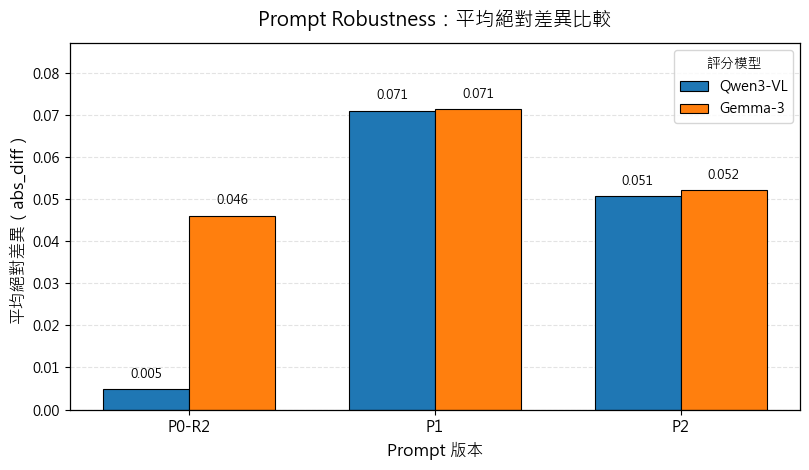

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# =========================
# 路徑設定
# =========================
ROOT = Path("/home/ester/valid_description")
FIG = ROOT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# =========================
# 中文字型設定：WSL / Windows 都可用
# =========================
font_candidates = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    "/mnt/c/Windows/Fonts/msjh.ttc",   # Windows 微軟正黑體
    "/mnt/c/Windows/Fonts/mingliu.ttc",
]

selected_font = None

for font_path in font_candidates:
    if Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        selected_font = fm.FontProperties(fname=font_path).get_name()
        break

if selected_font is None:
    print("⚠️ 找不到中文字型，請先執行：sudo apt install -y fonts-noto-cjk")
    selected_font = "DejaVu Sans"
else:
    print(f"使用中文字型：{selected_font}")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [selected_font, "DejaVu Sans"],
    "axes.unicode_minus": False,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

# =========================
# 資料路徑
# =========================
files = {
    "Qwen3-VL": {
        "P0-R2": ROOT / "Qwen3_Instruct/phase3_scores_Qwen3VL32B_robustness_run1_compare.csv",
        "P1": ROOT / "Qwen3_Instruct/phase3_scores_Qwen3VL32B_robustness_run1_compare_change.csv",
        "P2": ROOT / "Qwen3_Instruct/phase3_scores_Qwen3VL32B_robustness_run1_compare_conservative.csv",
    },
    "Gemma-3": {
        "P0-R2": ROOT / "Gemma3/phase3_scores_Gemma3_robustness_run1_compare.csv",
        "P1": ROOT / "Gemma3/phase3_scores_Gemma3_robustness_run1_compare_change.csv",
        "P2": ROOT / "Gemma3/phase3_scores_Gemma3_robustness_run1_compare_conservative.csv",
    },
}

labels = ["P0-R2", "P1", "P2"]
x = np.arange(len(labels))
width = 0.35

# =========================
# 繪圖
# =========================
fig, ax = plt.subplots(figsize=(8.2, 4.8))

for i, model in enumerate(["Qwen3-VL", "Gemma-3"]):
    values = []

    for label in labels:
        csv_path = files[model][label]

        if not csv_path.exists():
            raise FileNotFoundError(f"找不到檔案：{csv_path}")

        df = pd.read_csv(csv_path)

        if "abs_diff" not in df.columns:
            raise KeyError(f"{csv_path.name} 缺少 abs_diff 欄位，目前欄位：{list(df.columns)}")

        values.append(df["abs_diff"].mean())

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model,
        edgecolor="black",
        linewidth=0.8,
    )

    # 數值標示
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# =========================
# 座標軸與圖表格式
# =========================
ax.set_title("Prompt Robustness：平均絕對差異比較", fontsize=14, pad=12)
ax.set_xlabel("Prompt 版本", fontsize=12)
ax.set_ylabel("平均絕對差異（abs_diff）", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(title="評分模型", frameon=True)

# 讓 y 軸上方留空間放數字
ymax = max(
    pd.read_csv(files[model][label])["abs_diff"].mean()
    for model in files
    for label in labels
)
ax.set_ylim(0, ymax * 1.22)

# 保留完整圖框，論文圖比較清楚
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)

fig.tight_layout()

fig.savefig(FIG / "prompt_robustness_abs_diff.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG / "prompt_robustness_abs_diff.svg", bbox_inches="tight")

plt.show()